In [1]:
#%pylab nbaggpython
%matplotlib inline
#%matplotlib widget
import numpy as np
#import scipy.fftpack
#from brian2.units.constants import faraday_constant as F
import time
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from pytictoc import TicToc
from scipy.signal import argrelextrema
import scipy.optimize as opt

# Functions

In [2]:
def cubic_fit(vs, cubic):
    cmid=int(argrelextrema(cubic, np.less)[0][0])
    cpid=int(argrelextrema(cubic, np.greater)[0][0])
    cm=vs[cmid] # x-coordinate center minus
    cp=vs[cpid] # x-coordinate center plus
    im=cubic[cmid] # y-coordinate center minus
    ip=cubic[cpid] # y-coordinate center plus

    #Vstar where the two parabolas meet (curvature change)
    curvature=np.gradient(np.gradient(cubic[30:-5]))
    signchange=(np.diff(np.sign(curvature)) != 0)*1
    vst=vs[30+np.where(signchange==1)[0]][0]

    pm= ip-im

    # Curvature minus and plus is defined by imposing that:
    # 1) the two parabolas meet at Vstar 
    # 2) and the derivative at Vstar is continuous
    rp = (pm)/((cp-cm)*(vst-cp))
    rm = rp*(vst-cp)/(vst-cm)
        
    return vst, cm, im, rm, cp, ip, rp

In [3]:
def qfit(xdata,ydata):
    model, pcov = opt.curve_fit(fquad, xdata, ydata)
    model_ = fquad(xdata, *model)
    return model, model_

def fquad(x,a,b,c):
    y = a*x**2+b*x+c
    return y

In [4]:
import pickle

def save_obj(obj, name ):
    with open('/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/'+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

def load_obj(name ):
    with open('/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/'+ name + '.pkl', 'rb') as f:
        return pickle.load(f)

## Settings Single Neuron Model

In [5]:
# Carmela

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'K_bath': 12.5,  # mol.m**-3
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 
       'E': 0., #check
       
       ## Time costants
       'Cm': 1,#10, #1
       'tau_n': 4,#2.5,#4 
       'gamma': 0.04,  
       'epsilon': 0.001,
       'tau_I': 1
      }

In [6]:
def m_inf(V):
    return 1.0/(1.0+np.exp((Par['Cmna']-V)/Par['DCmna']))

def n_inf(V):
    return 1.0/(1.0+np.exp((Par['Cnk']-V)/Par['DCnk']))

def h(n):
    return 1.1 - 1.0 / (1.0 + np.exp(-8.0 * (n - 0.4)))

def I_K_form(V,n,K_o,K_i):
    return (Par['g_Kl']+Par['g_K']*n)*(V- 26.64*np.log(K_o/K_i)) 

def I_Na_form(V,Na_o,Na_i,n):
    return (Par['g_Nal']+Par['g_Na']*m_inf(V)*h(n))*(V- 26.64*np.log(Na_o/Na_i))

def I_Cl_form(V):
    return Par['g_Cl']*(V+ 26.64*np.log(Par['Cl_o0']/Par['Cl_i0'])) 

def I_pump_form(Na_i,K_o):
    return Par['rho']*(1.0/(1.0+np.exp((Par['Cnap'] - Na_i) / Par['DCnap']))*(1.0/(1.0+np.exp((Par['Ckp'] - K_o)/Par['DCkp'])))) 

def V_dot_form(I_Na,I_K,I_Cl,I_pump,V):
    return (-1.0/Par['Cm'])*(I_Na+I_K+I_Cl+I_pump)

def Kg_red(DKi,K_b):
    return (Par['w_i'] / Par['w_o'])*DKi + K_b - Par['K_o0']

def Kb_red(DKi,K_g):
    return -(Par['w_i'] / Par['w_o'])*DKi + K_g + Par['K_o0']

In [23]:
def neuron_model(z,t,kb):
    V = z[0]
    n = z[1]
    DKi = z[2]
    Kg = z[3]
    
    K_bath= kb
    
    beta= Par['w_i'] / Par['w_o'] 
    DNa_i = -DKi 
    DNa_o = -beta * DNa_i
    DK_o = -beta * DKi
    K_i = Par['K_i0'] + DKi 
    Na_i = Par['Na_i0'] + DNa_i 
    Na_o = Par['Na_o0'] + DNa_o 
    K_o = Par['K_o0'] + DK_o + Kg 

    I_Na = I_Na_form(V,Na_o,Na_i,n)
    I_Cl = I_Cl_form(V)
    I_pump = I_pump_form(Na_i,K_o)
    I_K = I_K_form(V,n,K_o,K_i)

    #%%%%%% Equations
    dV = V_dot_form(I_Na,I_K,I_Cl,I_pump,V)
    dn = (n_inf(V) - n) / Par['tau_n']
    dDKi = -(Par['gamma'] / Par['w_i']) * (I_K - 2.0 * I_pump)
    dKg = Par['epsilon'] * (K_bath - K_o)
    
    dz = [dV,dn,dDKi,dKg]

    return dz

In [24]:
z.shape

(20000, 4)

In [25]:
z0=[-15.0, 0.45, -5, -16.0]
K_bath_vec=[15.5]

In [26]:
min_2_sim=1/3
Np= int(min_2_sim*60*1000) #min in milliseconds 
t = np.linspace(0,Np,Np*1)

for ik, k in enumerate(K_bath_vec):
    z = odeint(neuron_model,z0,t,args=(k,))

In [27]:
x=z[-6000:,0]
V=z[-6000:,0]
n=z[-6000:,1]
DKi=z[-6000:,2]
Kg=z[-6000:,3]

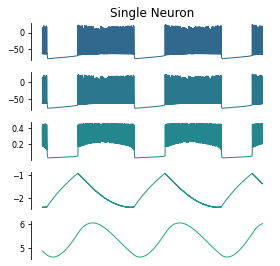

In [28]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 16)
print(viridis)

fig = plt.figure(figsize=(4,3.8))
ax1 = fig.add_subplot(511)
ax1.set_title('Single Neuron')
ax1.plot(x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
plt.show()

In [13]:
# For Carmela's regime
K_bath_vec=np.linspace(3.5,27.5,25)
K_bath_vec

array([ 3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5, 11.5, 12.5, 13.5,
       14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5,
       25.5, 26.5, 27.5])

## Run Single Neuron 4D model

In [16]:
Single_Carmela={}
z0 = [-15.0, 0.45, -3.5, -12.0]
min_2_sim=1/3
Np= int(min_2_sim*60*1000) #min in milliseconds 
t = np.linspace(0,Np,Np*10)

for ik, k in enumerate(K_bath_vec):
    z = odeint(neuron_model,z0,t,args=(k,))
    Single_Carmela[k]={} 
    Single_Carmela[k]['V']=z[:,0]
    Single_Carmela[k]['n']=z[:,1]
    Single_Carmela[k]['DK_i']=z[:,2]
    Single_Carmela[k]['Kg']=z[:,3]
    
save_obj(Single_Carmela,'Single_Carmela')
# Single=load_obj('Single_ABH_Cm5')
# K_bath_vec=Single.keys()

In [15]:
Single_Carmela=load_obj('Single_Carmela')


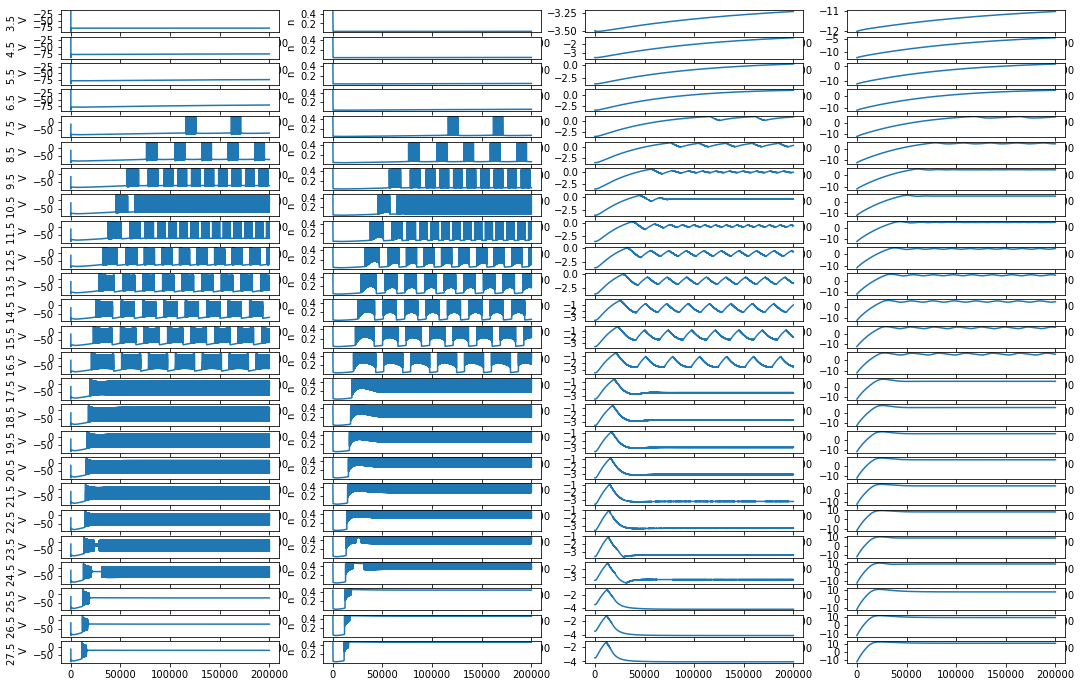

In [16]:
fig, axs = plt.subplots(len(K_bath_vec), 4, figsize=(18,12))
for ik, k in enumerate(K_bath_vec):
    axs[ik,0].plot(Single_Carmela[k]['V']);axs[ik,0].set_ylabel('%.1f \n V'%k)
    axs[ik,1].plot(Single_Carmela[k]['n']);axs[ik,1].set_ylabel('n')
    axs[ik,2].plot(Single_Carmela[k]['DK_i']);
    axs[ik,3].plot(Single_Carmela[k]['Kg']);
plt.show()

## Extract parabolas

In [17]:
Vs=np.arange(-80,0)

In [52]:
tlen=100000
Vdot=np.zeros((len(K_bath_vec), len(Vs)))
for ik, k in enumerate(K_bath_vec):
    for ii, i in enumerate(Vs):
        n= np.max(Single_Carmela[k]['n'][::10][-tlen:])
        DK_i= np.mean(Single_Carmela[k]['DK_i'][::10][-tlen:])
        Kg= np.mean(Single_Carmela[k]['Kg'][::10][-tlen:])

        beta= Par['w_i'] / Par['w_o']
        DNa_i = -DK_i 
        DNa_o = -beta * DNa_i
        DK_o = -beta * DK_i
        K_i = Par['K_i0'] + DK_i 
        Na_i = Par['Na_i0'] + DNa_i 
        Na_o = Par['Na_o0'] + DNa_o 
        K_o = Par['K_o0'] + DK_o + Kg 

        I_K = I_K_form(i,n,K_o,K_i)
        I_Na = I_Na_form(i,Na_o,Na_i,n)
        I_Cl = I_Cl_form(i)
        I_pump = I_pump_form(Na_i,K_o)
        Vdot[ik,ii]=V_dot_form(I_Na,I_K,I_Cl,I_pump,i)

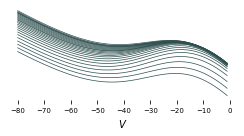

In [53]:
f, ax = plt.subplots(figsize=(3.5, 2.))
for i in range(len(K_bath_vec)):
    plt.plot(Vs,Vdot[i,:],c='darkslategray',alpha=1,linewidth=.7)
ax.set_frame_on(False)
ax.tick_params(axis='both',labelsize=7)
plt.yticks([])
ax.set_xlabel('$V$')
plt.tight_layout()
plt.savefig('Figures/vdot_kbath.pdf', transparent=True, format="PDF")
plt.show()

In [54]:
vst= np.zeros(len(K_bath_vec))
cm= np.zeros(len(K_bath_vec))
im= np.zeros(len(K_bath_vec))
rm= np.zeros(len(K_bath_vec))
cp= np.zeros(len(K_bath_vec))
ip= np.zeros(len(K_bath_vec))
rp = np.zeros(len(K_bath_vec))
for i in range(len(K_bath_vec)):
    vst[i], cm[i], im[i], rm[i], cp[i], ip[i], rp[i]= cubic_fit(Vs,Vdot[i,:])

In [41]:
print('c_minus=%.3f'%np.mean(cm))
print('c_plus=%.3f'%np.mean(cp))
print('R_minus=%.3f'%np.mean(rm))
print('R_plus=%.3f'%np.mean(rp))

c_minus=-44.240
c_plus=-20.400
R_minus=0.337
R_plus=-0.381


In [95]:
print('c_minus=%.3f'%np.mean(cm))
print('c_plus=%.3f'%np.mean(cp))
print('I_minus=%.3f'%np.mean(im))
print('I_plus=%.3f'%np.mean(ip))
print('R_minus=%.3f'%np.mean(rm))
print('R_plus=%.3f'%np.mean(rp))

c_minus=-44.240
c_plus=-20.400
I_minus=-213.074
I_plus=-106.665
R_minus=0.337
R_plus=-0.381


# Supplementary

In [56]:
Cm_c, Cm_f = qfit(K_bath_vec,cm)
Rm_c, Rm_f = qfit(K_bath_vec,rm)
Cp_c, Cp_f = qfit(K_bath_vec,cp)
Rp_c, Rp_f = qfit(K_bath_vec,rp)

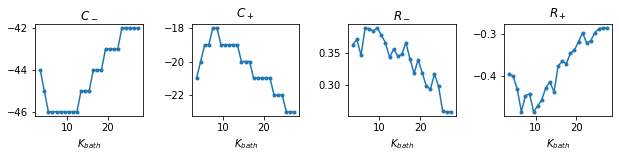

In [59]:
plt.figure(figsize=(8.7,2.3))
plt.subplot(1,4,1);plt.title('$C_-$')
plt.plot(K_bath_vec,cm,'.-');#plt.plot(K_bath_vec,Cm_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,2);plt.title('$C_+$')
plt.plot(K_bath_vec,cp,'.-');#plt.plot(K_bath_vec,Cp_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,3);plt.title('$R_-$')
plt.plot(K_bath_vec,rm,'.-');#plt.plot(K_bath_vec,Rm_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,4);plt.title('$R_+$')
plt.plot(K_bath_vec,rp,'.-');#plt.plot(K_bath_vec,Rp_f)
plt.xlabel('$K_{bath}$')

plt.tight_layout()
plt.savefig('Figures/coeffVSkb.pdf', transparent=True, format="PDF")
plt.show()

In [122]:
tlen=6000
Vdot=np.zeros((len(K_bath_vec), len(Vs),tlen))
for ik, k in enumerate(K_bath_vec):
    for ii, i in enumerate(Vs):
        for j in range(tlen):
            V= Single_Carmela[k]['V'][::10][-tlen:][j]
            n= Single_Carmela[k]['n'][::10][-tlen:][j]
            DK_i= Single_Carmela[k]['DK_i'][::10][-tlen:][j]
            Kg= Single_Carmela[k]['Kg'][::10][-tlen:][j]

            beta= Par['w_i'] / Par['w_o']
            DNa_i = -DK_i 
            DNa_o = -beta * DNa_i
            DK_o = -beta * DK_i
            K_i = Par['K_i0'] + DK_i 
            Na_i = Par['Na_i0'] + DNa_i 
            Na_o = Par['Na_o0'] + DNa_o 
            K_o = Par['K_o0'] + DK_o + Kg 

            I_K = I_K_form(i,n,K_o,K_i)
            I_Na = I_Na_form(i,Na_o,Na_i,n)
            I_Cl = I_Cl_form(i)
            I_pump = I_pump_form(Na_i,K_o)
            Vdot[ik,ii,j]=V_dot_form(I_Na,I_K,I_Cl,I_pump,i)

In [65]:
len(Vs)

80

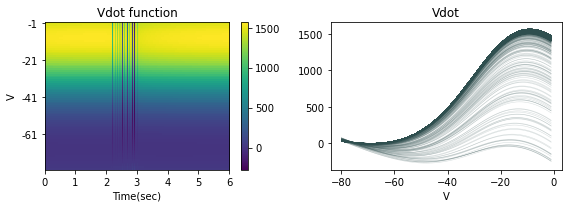

In [67]:
ikk=4
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.title('Vdot function')
plt.imshow(Vdot[ikk,::-1,:],aspect='auto',interpolation='nearest')
plt.yticks(np.arange(80)[::20],np.arange(-80,0)[::-1][::20])
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6])
plt.xlabel('Time(sec)')
plt.ylabel('V')
plt.colorbar()
plt.subplot(1,2,2)
plt.title('Vdot')
for i in range(int(tlen/4)):
    plt.plot(Vs,Vdot[ikk,:,int(4*i)],c='darkslategray',alpha=0.2,linewidth=0.5)
plt.xlabel('V')
plt.tight_layout()
plt.savefig('Figures/Vdot_t.pdf', transparent=True, format="PDF")
plt.show()

In [171]:
Vdot.shape

(25, 80, 6000)

In [178]:
def cubic_fit(vs, cubic):
    cmid=int(argrelextrema(cubic, np.less)[0][0])
    cpid=int(argrelextrema(cubic, np.greater)[0][0])
    cm=vs[cmid] # x-coordinate center minus
    cp=vs[cpid] # x-coordinate center plus
    im=cubic[cmid] # y-coordinate center minus
    ip=cubic[cpid] # y-coordinate center plus

    #Vstar where the two parabolas meet (curvature change)
    curvature=np.gradient(np.gradient(cubic[30:-5]))
    signchange=(np.diff(np.sign(curvature)) != 0)*1
    vst=vs[30+np.where(signchange==1)[0]][0]

    pm= ip-im

    # Curvature minus and plus is defined by imposing that:
    # 1) the two parabolas meet at Vstar 
    # 2) and the derivative at Vstar is continuous
    rp = (pm)/((cp-cm)*(vst-cp))
    rm = rp*(vst-cp)/(vst-cm)
        
    return vst, cm, im, rm, cp, ip, rp

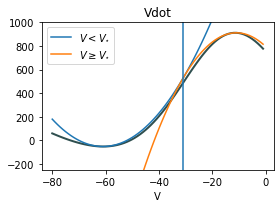

In [190]:
ikk=4
it=2950
plt.figure(figsize=(4,3))
plt.title('Vdot')
plt.plot(Vs,Vdot[ikk,:,it],c='darkslategray',alpha=1,linewidth=2.)
plt.plot(Vs,Rm[ikk,it]*((Vs-Cm[ikk,it])**2)+Im[ikk,it],label='$V<V_{\star}$')
plt.plot(Vs,Rp[ikk,it]*((Vs-Cp[ikk,it])**2)+Ip[ikk,it],label='$V\geq V_{\star}$')
plt.axvline(Vst[ikk,it])
plt.ylim(-250,1000)
plt.xlabel('V')
plt.legend()
plt.tight_layout()
plt.savefig('Figures/Vdot_fit.pdf', transparent=True, format="PDF")
plt.show()

In [179]:
Vst=np.zeros((len(K_bath_vec),tlen))
Cm=np.zeros((len(K_bath_vec),tlen))
Im=np.zeros((len(K_bath_vec),tlen))
Rm=np.zeros((len(K_bath_vec),tlen))
Cp=np.zeros((len(K_bath_vec),tlen))
Ip=np.zeros((len(K_bath_vec),tlen))
Rp=np.zeros((len(K_bath_vec),tlen))
for ik, k in enumerate(K_bath_vec):
    for ij in range(tlen):
        Vst[ik,ij], Cm[ik,ij], Im[ik,ij], Rm[ik,ij], Cp[ik,ij], Ip[ik,ij], Rp[ik,ij] = cubic_fit(Vs, Vdot[ik,:,ij])

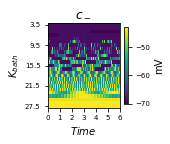

In [152]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$c_-$',fontsize=12)
plt.imshow(Cm,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
#plt.savefig('Figures/Cmin.pdf') 
plt.show()

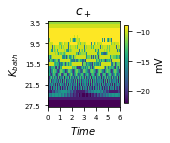

In [153]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$c_+$',fontsize=12)
plt.imshow(Cp,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
#plt.savefig('Figures/Cplus.pdf') 
plt.show()

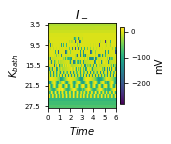

In [131]:
plt.figure(figsize=(2.4,2.1))
plt.title('$I_-$',fontsize=12)
plt.imshow(Im,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
plt.savefig('Figures/Imin.pdf') 
plt.show()

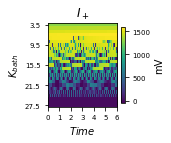

In [132]:
plt.figure(figsize=(2.4,2.1))
plt.title('$I_+$',fontsize=12)
plt.imshow(Ip,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
plt.savefig('Figures/Iplus.pdf') 
plt.show()

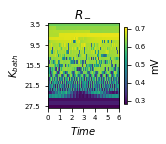

In [138]:
plt.figure(figsize=(2.35,2.1))
plt.title('$R_-$',fontsize=12)
plt.imshow(Rm,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
plt.savefig('Figures/Rmin.pdf') 
plt.show()

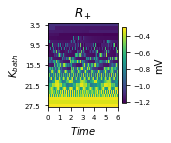

In [139]:
plt.figure(figsize=(2.4,2.1))
plt.title('$R_+$',fontsize=12)
plt.imshow(Rp,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
plt.savefig('Figures/Rplus.pdf') 
plt.show()

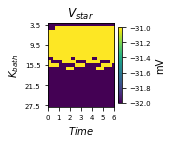

In [140]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$V_{star}$',fontsize=12)
plt.imshow(Vst,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
plt.savefig('Figures/Vst.pdf') 
plt.show()

In [191]:
VST=np.zeros((len(K_bath_vec),tlen))
CM=np.zeros((len(K_bath_vec),tlen))
IM=np.zeros((len(K_bath_vec),tlen))
RM=np.zeros((len(K_bath_vec),tlen))
CP=np.zeros((len(K_bath_vec),tlen))
IP=np.zeros((len(K_bath_vec),tlen))
RP=np.zeros((len(K_bath_vec),tlen))
for ik, k in enumerate(K_bath_vec):
    order=np.argsort(Single_Carmela[k]['V'][::10][-tlen:])
    CM[ik,:]=Cm[ik,order]
    IM[ik,:]=Im[ik,order]
    RM[ik,:]=Rm[ik,order]
    CP[ik,:]=Cp[ik,order]
    IP[ik,:]=Ip[ik,order]
    RP[ik,:]=Rp[ik,order]
    VST[ik,:]=Vst[ik,order]


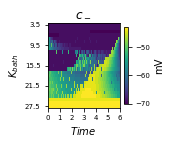

In [192]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$c_-$',fontsize=12)
plt.imshow(CM,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
#plt.savefig('Figures/Cmin.pdf') 
plt.show()

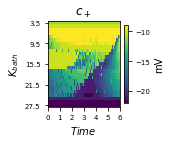

In [193]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$c_+$',fontsize=12)
plt.imshow(CP,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
#plt.savefig('Figures/Cmin.pdf') 
plt.show()

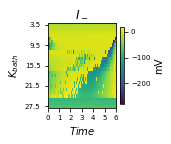

In [194]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$I_-$',fontsize=12)
plt.imshow(IM,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
#plt.savefig('Figures/Cmin.pdf') 
plt.show()

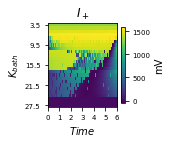

In [195]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$I_+$',fontsize=12)
plt.imshow(IP,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
#plt.savefig('Figures/Cmin.pdf') 
plt.show()

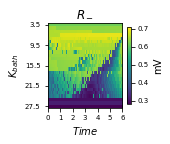

In [196]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$R_-$',fontsize=12)
plt.imshow(RM,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
#plt.savefig('Figures/Cmin.pdf') 
plt.show()

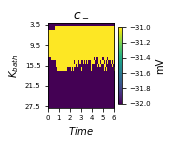

In [197]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$c_-$',fontsize=12)
plt.imshow(VST,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(len(K_bath_vec))[::6],K_bath_vec[::6],fontsize=7)
plt.xticks([0,1000,2000,3000,4000,5000,6000],[0,1,2,3,4,5,6],fontsize=7)
plt.ylabel('$K_{bath}$')
plt.xlabel('$Time$')
plt.tight_layout()
#plt.savefig('Figures/Cmin.pdf') 
plt.show()

# OLD

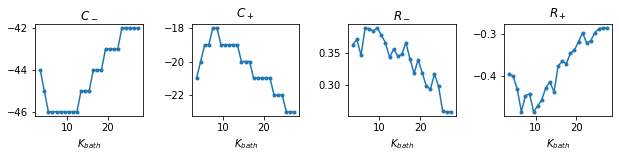

In [60]:
plt.figure(figsize=(8.7,2.3))
plt.subplot(1,4,1);plt.title('$C_-$')
plt.plot(K_bath_vec,cm,'.-');#plt.plot(K_bath_vec,Cm_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,2);plt.title('$C_+$')
plt.plot(K_bath_vec,cp,'.-');#plt.plot(K_bath_vec,Cp_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,3);plt.title('$R_-$')
plt.plot(K_bath_vec,rm,'.-');#plt.plot(K_bath_vec,Rm_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,4);plt.title('$R_+$')
plt.plot(K_bath_vec,rp,'.-');#plt.plot(K_bath_vec,Rp_f)
plt.xlabel('$K_{bath}$')

plt.tight_layout()
plt.savefig('Figures/coeffVSkb.pdf', transparent=True, format="PDF")
plt.show()

In [ ]:
cm= np.zeros(len(K_bath_vec))
im= np.zeros(len(K_bath_vec))
rm= np.zeros(len(K_bath_vec))
cp= np.zeros(len(K_bath_vec))
ip= np.zeros(len(K_bath_vec))
rp = np.zeros(len(K_bath_vec))

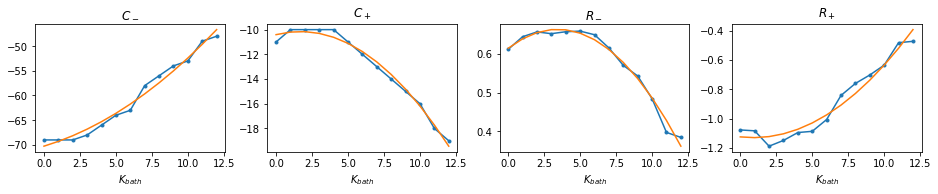

In [72]:
plt.figure(figsize=(13,2.8))
plt.subplot(1,4,1);plt.title('$C_-$')
plt.plot(cm,'.-');plt.plot(Cm_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,2);plt.title('$C_+$')
plt.plot(cp,'.-');plt.plot(Cp_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,3);plt.title('$R_-$')
plt.plot(rm,'.-');plt.plot(Rm_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,4);plt.title('$R_+$')
plt.plot(rp,'.-');plt.plot(Rp_f)
plt.xlabel('$K_{bath}$')

plt.tight_layout()
plt.show()

In [509]:
c_minus=-44.240
c_plus=-20.400
R_minus=0.337
R_plus=-0.381
V_star=-40

def V_dot_form_red(rminus,cminus,rplus,cplus,vstar,V,n):
    vdot=np.zeros(len(V))
    for i in range(len(V)):
        if V[i]<vstar:
            vdot[i]= (0.2*n[i]-0.022)*rminus*(V[i]-cminus)**2
        else:
            vdot[i]= (0.2*n[i]-0.022)*rplus*(V[i]-cplus)**2
    return vdot

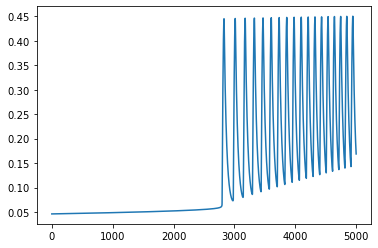

In [510]:
plt.plot(Single_Carmela[15.5]['n'][20000:25000])

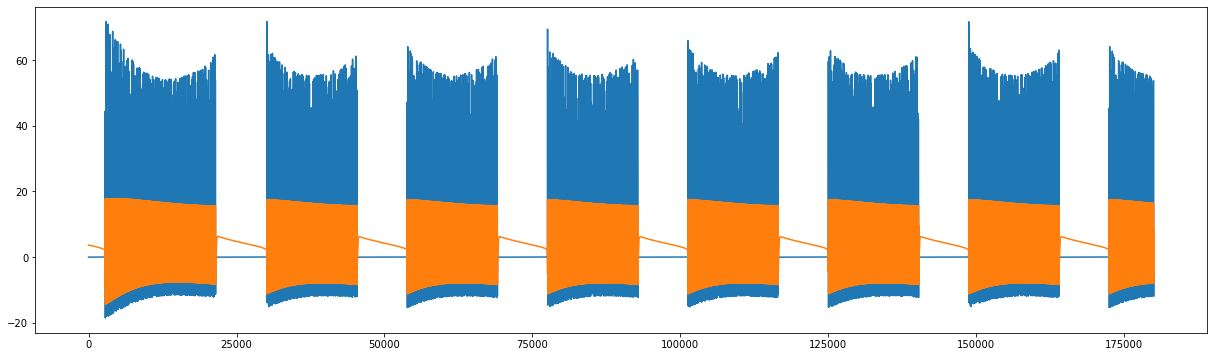

In [512]:
plt.figure(figsize=(21,6))
plt.plot(np.diff(Single_Carmela[15.5]['V'][20000:]))
plt.plot(-V_dot_form_red(R_minus,c_minus,R_plus,c_plus,V_star,Single_Carmela[15.5]['V'][20000:],Single_Carmela[15.5]['n'][20000:]))
plt.show()

## Reduced Single Neuron Model

In [96]:
# Carmela

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'K_bath': 12.5,  # mol.m**-3
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 
       'E': 0., #check
       
       ## Time costants
       'Cm': 1,#10, #1
       'tau_n': 4,#2.5,#4 
       'gamma': 0.04,  
       'epsilon': 0.001,
       'tau_I': 1
      }

In [207]:

def V_dot_form_red(vm,vp,a,rminus,cminus,rplus,cplus,vstar,V,n,Na_o,Na_i,K_o,K_i):
    if V<vstar:
        I_Na = I_Na_form(vm,Na_o,Na_i,n)
        I_Cl = I_Cl_form(vm)
        I_pump = I_pump_form(Na_i,K_o)
        I_K = I_K_form(vm,n,K_o,K_i)
        vdot= rminus*((V-cminus)**2+a*(I_Na+I_Cl+I_K+I_pump))
    else:
        I_Na = I_Na_form(vm,Na_o,Na_i,n)
        I_Cl = I_Cl_form(vm)
        I_pump = I_pump_form(Na_i,K_o)
        I_K = I_K_form(vm,n,K_o,K_i)
        vdot= rplus*((V-cplus)**2+a*(I_Na+I_Cl+I_K+I_pump))
    return vdot

In [517]:
#%%%%%% Equations

def V_dot_form_red(rminus,cminus,rplus,cplus,vstar,V,I_Na,I_K,I_Cl,I_pump,SubV):
    if V<vstar:
        vdot= rminus*((V-cminus)**2)+V_dot_form(I_Na,I_K,I_Cl,I_pump,SubV)
    else:
        vdot= rplus*((V-cplus)**2)+V_dot_form(I_Na,I_K,I_Cl,I_pump,SubV)
    return vdot

In [519]:
#%%%%%% Equations

def V_dot_form_red(rminus,cminus,rplus,cplus,vstar,V,n):
    if V<vstar:
        vdot= (0.2*n-0.022)*rminus*((V-cminus)**2)
    else:
        vdot= (0.2*n-0.022)*rplus*((V-cplus)**2)
    return vdot

In [520]:
def neuron_model_red(z,t,kb):
    V = z[0]
    n = z[1]
    DKi = z[2]
    Kg = z[3]
    
    K_bath= kb
    
    beta= Par['w_i'] / Par['w_o'] 
    DNa_i = -DKi 
    DNa_o = -beta * DNa_i
    DK_o = -beta * DKi
    K_i = Par['K_i0'] + DKi 
    Na_i = Par['Na_i0'] + DNa_i 
    Na_o = Par['Na_o0'] + DNa_o 
    K_o = Par['K_o0'] + DK_o + Kg 
    
    c_minus=-44.240
    c_plus=-20.400
    R_minus=0.337
    R_plus=-0.381
    V_star=-40
    
    #%%%%%% Equations
    dn = (n_inf(V) - n) / Par['tau_n']
    dV = V_dot_form_red(R_minus,c_minus,R_plus,c_plus,V_star,V,n)
    dDKi = -(Par['gamma'] / Par['w_i']) * (I_K - 2.0 * I_pump)
    dKg = Par['epsilon'] * (K_bath - K_o)
    
    dz = [dV,dn,dDKi,dKg]

    return dz

In [427]:
def neuron_model_red(z,t,kb):
    V = z[0]
    n = z[1]
    DKi = z[2]
    Kg = z[3]
    
    K_bath= kb
    
    beta= Par['w_i'] / Par['w_o'] 
    DNa_i = -DKi 
    DNa_o = -beta * DNa_i
    DK_o = -beta * DKi
    K_i = Par['K_i0'] + DKi 
    Na_i = Par['Na_i0'] + DNa_i 
    Na_o = Par['Na_o0'] + DNa_o 
    K_o = Par['K_o0'] + DK_o + Kg 
    
    c_minus=-44.240
    c_plus=-20.400
    R_minus=0.337
    R_plus=-0.381
    V_star=-40
    
    #%%%%%% Equations
    dn = (n_inf(V) - n) / Par['tau_n']
    
    subV=V+dn
    
    I_Na = I_Na_form(subV,Na_o,Na_i,n)
    I_Cl = I_Cl_form(subV)
    I_pump = I_pump_form(Na_i,K_o)
    I_K = I_K_form(subV,n,K_o,K_i)
    
    dV = V_dot_form_red(R_minus,c_minus,R_plus,c_plus,V_star,V,I_Na,I_K,I_Cl,I_pump,subV)
    dDKi = -(Par['gamma'] / Par['w_i']) * (I_K - 2.0 * I_pump)
    dKg = Par['epsilon'] * (K_bath - K_o)
    
    dz = [dV,dn,dDKi,dKg]

    return dz

In [433]:
#%%%%%% Equations

def V_dot_form_red(I_Na,I_K,I_Cl,I_pump,SubV):
    return V_dot_form(I_Na,I_K,I_Cl,I_pump,SubV)


In [456]:
def neuron_model_red(z,t,kb):
    V = z[0]
    n = z[1]
    DKi = z[2]
    Kg = z[3]
    
    K_bath= kb
    
    beta= Par['w_i'] / Par['w_o'] 
    DNa_i = -DKi 
    DNa_o = -beta * DNa_i
    DK_o = -beta * DKi
    K_i = Par['K_i0'] + DKi 
    Na_i = Par['Na_i0'] + DNa_i 
    Na_o = Par['Na_o0'] + DNa_o 
    K_o = Par['K_o0'] + DK_o + Kg 
    
    c_minus=-44.240
    c_plus=-20.400
    R_minus=0.337
    R_plus=-0.381
    V_star=-40
    
    #%%%%%% Equations
    dn = (n_inf(V) - n) / Par['tau_n']
    
    subV=10*(n+dn)
    
    I_Na = I_Na_form(subV,Na_o,Na_i,n)
    I_Cl = I_Cl_form(subV)
    I_pump = I_pump_form(Na_i,K_o)
    I_K = I_K_form(subV,n,K_o,K_i)
    
    dV = V_dot_form_red(I_Na,I_K,I_Cl,I_pump,subV)
    dDKi = -(Par['gamma'] / Par['w_i']) * (I_K - 2.0 * I_pump)
    dKg = Par['epsilon'] * (K_bath - K_o)
    
    dz = [dV,dn,dDKi,dKg]

    return dz

## Run Single Neuron 4D model

In [521]:
#save_obj(Single_Carmela,'Single_Carmela')
#Single_Carmela=load_obj('Single_Carmela')

# For Carmela's regime
K_bath_vec=[15.5]
K_bath_vec

[15.5]

In [522]:
Single_Carmela_red={}
z0 = [-15.0, 0.45, -3.5, -12.0]
min_2_sim=1/3
Np= int(min_2_sim*60*1000) #min in milliseconds 
t = np.linspace(0,Np,Np*10)

for ik, k in enumerate(K_bath_vec):
    z = odeint(neuron_model_red,z0,t,args=(k,))
    Single_Carmela_red[k]={} 
    Single_Carmela_red[k]['V']=z[:,0]
    Single_Carmela_red[k]['n']=z[:,1]
    Single_Carmela_red[k]['DK_i']=z[:,2]
    Single_Carmela_red[k]['Kg']=z[:,3]

In [523]:
k

15.5

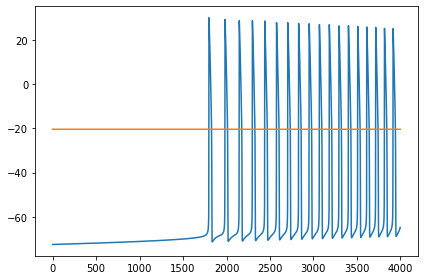

In [524]:
plt.figure()
plt.plot(Single_Carmela[k]['V'][21000:25000])
plt.plot(Single_Carmela_red[k]['V'][21000:25000])
plt.tight_layout()
plt.show()

In [29]:
len(K_bath_vec)

25

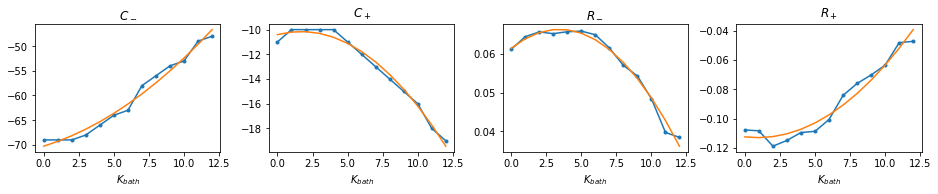

In [187]:
plt.figure(figsize=(13,2.8))
plt.subplot(1,4,1);plt.title('$C_-$')
plt.plot(cm,'.-');plt.plot(Cm_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,2);plt.title('$C_+$')
plt.plot(cp,'.-');plt.plot(Cp_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,3);plt.title('$R_-$')
plt.plot(rm,'.-');plt.plot(Rm_f)
plt.xlabel('$K_{bath}$')

plt.subplot(1,4,4);plt.title('$R_+$')
plt.plot(rp,'.-');plt.plot(Rp_f)
plt.xlabel('$K_{bath}$')

plt.tight_layout()
plt.show()

In [182]:
def namestr(obj, namespace):
    return [name for name in namespace if namespace[name] is obj]

def extract_coef(coef_array):
    fivepc2=coef_array[0]/100*5
    fivepc1=coef_array[1]/100*5
    fivepc0=coef_array[2]/100*5
    print(namestr(coef_array,globals())[0]+'2=['+str(coef_array[0]-4*fivepc2)+','+str(coef_array[0]-3*fivepc2)+','+str(coef_array[0]-2*fivepc2)+','+str(coef_array[0]-fivepc2)+','+str(coef_array[0])+','+str(coef_array[0]+fivepc2)+','+str(coef_array[0]+2*fivepc2)+','+str(coef_array[0]+3*fivepc2)+','+str(coef_array[0]+4*fivepc2)+']')
    print(namestr(coef_array,globals())[0]+'1=['+str(coef_array[1]-4*fivepc1)+','+str(coef_array[1]-3*fivepc1)+','+str(coef_array[1]-2*fivepc1)+','+str(coef_array[1]-fivepc1)+','+str(coef_array[1])+','+str(coef_array[1]+fivepc1)+','+str(coef_array[1]+2*fivepc1)+','+str(coef_array[1]+3*fivepc1)+','+str(coef_array[1]+4*fivepc1)+']')
    print(namestr(coef_array,globals())[0]+'0=['+str(coef_array[2]-4*fivepc0)+','+str(coef_array[2]-3*fivepc0)+','+str(coef_array[2]-2*fivepc0)+','+str(coef_array[2]-fivepc0)+','+str(coef_array[2])+','+str(coef_array[2]+fivepc0)+','+str(coef_array[2]+2*fivepc0)+','+str(coef_array[2]+3*fivepc0)+','+str(coef_array[2]+4*fivepc0)+']')

In [184]:
extract_coef(Cm_c)
extract_coef(Cp_c)
extract_coef(Rm_c)
extract_coef(Rp_c)

Cm_c2=[0.018181818180112153,0.019318181816369163,0.02045454545262617,0.02159090908888318,0.02272727272514019,0.0238636363613972,0.02499999999765421,0.026136363633911218,0.027272727270168228]
Cm_c1=[0.22317682317558613,0.23712537462406028,0.2510739260725344,0.26502247752100855,0.27897102896948267,0.2929195804179568,0.3068681318664309,0.3208166833149051,0.3347652347633792]
Cm_c0=[-57.21483516496188,-60.790762362772,-64.36668956058212,-67.94261675839223,-71.51854395620235,-75.09447115401247,-78.67039835182258,-82.2463255496327,-85.82225274744282]
Cp_c2=[-0.0174825174400573,-0.01857517478006088,-0.01966783212006446,-0.020760489460068043,-0.021853146800071624,-0.022945804140075205,-0.024038461480078786,-0.025131118820082367,-0.02622377616008595]
Cp_c1=[0.24085913945073179,0.25591283566640255,0.27096653188207326,0.28602022809774397,0.30107392431341473,0.3161276205290855,0.3311813167447562,0.3462350129604269,0.3612887091760977]
Cp_c0=[-8.954120869305608,-9.51375342363721,-10.07338597796881,-1

In [170]:
extract_coef(Cp_c)

Cp_c2=[-0.01966783212006446,-0.020760489460068043,-0.021853146800071624,-0.022945804140075205,-0.024038461480078786]
Cp_c1=[0.27096653188207326,0.28602022809774397,0.30107392431341473,0.3161276205290855,0.3311813167447562]
Cp_c0=[-10.07338597796881,-10.633018532300412,-11.192651086632011,-11.752283640963611,-12.311916195295213]


In [171]:
extract_coef(Rm_c)

Rm_c2=[-9.285282627354222e-05,-9.801131662207235e-05,-0.00010316980697060247,-0.0001083282973191326,-0.00011348678766766272]
Rm_c1=[0.001929870116246708,0.0020370851227048585,0.002144300129163009,0.002251515135621159,0.00235873014207931]
Rm_c0=[0.049705945200130025,0.05246738660013724,0.05522882800014447,0.057990269400151694,0.06075171080015891]


In [172]:
extract_coef(Rp_c)

Rp_c2=[0.00013493018307776872,0.000142426304359867,0.00014992242564196526,0.0001574185469240635,0.0001649146682061618]
Rp_c1=[-0.0014372177445484404,-0.0015170631748011316,-0.0015969086050538228,-0.001676754035306514,-0.001756599465559205]
Rp_c0=[-0.09791814057760526,-0.1033580372763611,-0.10879793397511694,-0.11423783067387279,-0.11967772737262863]


In [ ]:
cm=cm2*kb**2+cm1*kb+cm0
cp=cp2*kb**2+cp1*kb+cp0
rm=rm2*kb**2+rm1*kb+rm0
rp=rp2*kb**2+rp1*kb+rp0

In [164]:
Cm_c[1]

0.27897102896948267

In [ ]:
Cm_c[1]/100*5

In [177]:
12*5

60

In [178]:
60*60

3600

# BACKUP

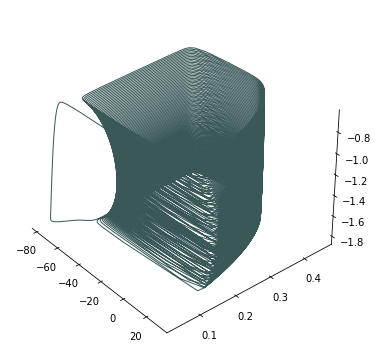

In [13]:
ikk=13.5
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
  
fig = plt.figure(figsize=plt.figaspect(0.5)*1.25)

ax = plt.axes(projection = '3d')

ti=-40000
tf=-20000
x=Single[ikk]['V'][ti:tf]
y=Single[ikk]['n'][ti:tf]
z=Single[ikk]['DK_i'][ti:tf]
  
ax.plot3D(x, y, z, 'darkslategray', alpha=0.95,linewidth=1)
  
ax.view_init(35, -40)
#ax.set_box_aspect(aspect = (1,1,0.85))

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# make the grid lines transparent
ax.xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.zaxis._axinfo["grid"]['color'] =  (1,1,1,0)

#ax.set_axis_off()

plt.tight_layout()  
#plt.savefig('Figures/3d.png', dpi=300)
plt.show()

In [7]:
K_bath_vec=np.linspace(6.,20.,15)
K_bath_vec

array([ 6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18.,
       19., 20.])

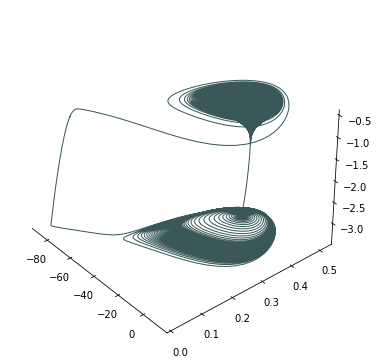

In [230]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
  
fig = plt.figure(figsize=plt.figaspect(0.5)*1.25)

ax = plt.axes(projection = '3d')

x=Single[ikk]['V'][-100000:]
y=Single[ikk]['n'][-100000:]
z=Single[ikk]['DK_i'][-100000:]
  
ax.plot3D(x, y, z, 'darkslategray', alpha=0.95,linewidth=1)
  
ax.view_init(35, -40)
#ax.set_box_aspect(aspect = (1,1,0.85))

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# make the grid lines transparent
ax.xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.zaxis._axinfo["grid"]['color'] =  (1,1,1,0)

#ax.set_axis_off()

plt.tight_layout()  
plt.savefig('3d.png', dpi=300)
plt.show()

In [10]:
tlen=len(Single[9]['V'])

(37.0, 38.0)

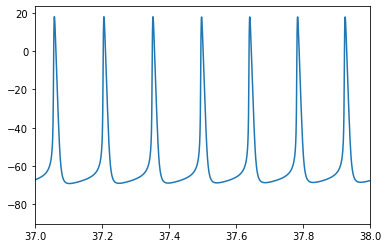

In [14]:
plt.plot(np.linspace(0,60,tlen),Single[9]['V'])
plt.xlim(37,38)

In [12]:
# beta= Par['w_i'] / Par['w_o'] 
# Kext = Par['K_o0'] + -beta * Single[ikk]['DK_i'][-100000:] + Single[ikk]['Kg'][-100000:] 

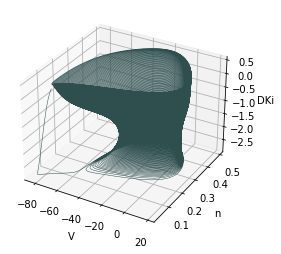

In [24]:
ikk=10
fig = plt.figure(figsize=(4,3.5))
ax = fig.add_subplot(111, projection='3d')
ax.plot(Single[ikk]['V'][50000:100000],Single[ikk]['n'][50000:100000],Single[ikk]['DK_i'][50000:100000],linewidth=0.5,c='darkslategray')
ax.set_xlabel("V");ax.set_ylabel("n");ax.set_zlabel("DKi"); 
#ax.view_init(elev=30., azim=120)
plt.tight_layout()
plt.show()

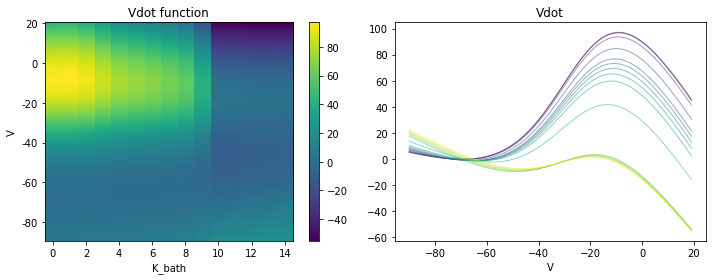

In [248]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Vdot function')
plt.imshow(Vdot[:,::-1].T,aspect='auto',interpolation='none')
plt.yticks(np.arange(110)[::20],np.arange(-89,21)[::-1][::20])
plt.xlabel('K_bath')
plt.ylabel('V')
plt.colorbar()
plt.subplot(1,2,2)
plt.title('Vdot')
for i in range(len(K_bath_vec)):
    plt.plot(Vs,Vdot[i,:],c=viridis((i)/len(K_bath_vec)),alpha=0.5,linewidth=1.)
cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=K_bath_vec[0], vmax=K_bath_vec[-1])

cb1 = mpl.colorbar.ColorbarBase(ax,cmap=cmap,
                                norm=norm,
                                orientation='horizontal')
plt.xlabel('V')
plt.tight_layout()
plt.show()

In [207]:
len(K_bath_vec)/(0+1)

15.0

In [198]:
1./(i+1)

1.0

In [188]:
len(K_bath_vec)

15

In [ ]:
tlen=6000
Vdot=np.zeros((len(K_bath_vec), len(Vs),tlen))
for ik, k in enumerate(K_bath_vec):
    for ii, i in enumerate(Vs):
        for j in range(tlen):
            V= Single[k]['V'][::10][-tlen:][j]
            n= Single[k]['n'][::10][-tlen:][j]
            DK_i= Single[k]['DK_i'][::10][-tlen:][j]
            Kg= Single[k]['Kg'][::10][-tlen:][j]

            beta= Par['w_i'] / Par['w_o']
            DNa_i = -DK_i 
            DNa_o = -beta * DNa_i
            DK_o = -beta * DK_i
            K_i = Par['K_i0'] + DK_i 
            Na_i = Par['Na_i0'] + DNa_i 
            Na_o = Par['Na_o0'] + DNa_o 
            K_o = Par['K_o0'] + DK_o + Kg 

            I_K = I_K_form(i,n,K_o,K_i)
            I_Na = I_Na_form(i,Na_o,Na_i,n)
            I_Cl = I_Cl_form(i)
            I_pump = I_pump_form(Na_i,K_o)
            Vdot[ik,ii,j]=V_dot_form(I_Na,I_K,I_Cl,I_pump,i)

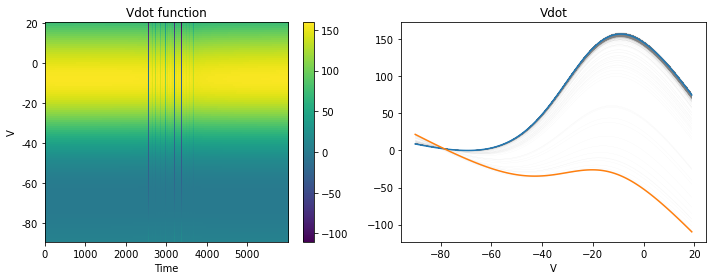

In [255]:
ikk=2
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Vdot function')
plt.imshow(Vdot[ikk,::-1,:],aspect='auto',interpolation='none')
plt.yticks(np.arange(110)[::20],np.arange(-89,21)[::-1][::20])
plt.xlabel('Time')
plt.ylabel('V')
plt.colorbar()
plt.subplot(1,2,2)
plt.title('Vdot')
for i in range(int(tlen/4)):
    plt.plot(Vs,Vdot[ikk,:,int(4*i)],c='gray',alpha=0.2,linewidth=0.1)
wre_m=np.argmin(Vdot[ikk,0,:])
wre_p=np.argmax(Vdot[ikk,0,:])
plt.plot(Vs,Vdot[ikk,:,wre_m])
plt.plot(Vs,Vdot[ikk,:,wre_p])
plt.xlabel('V')
plt.tight_layout()
plt.show()

In [260]:
Vst=np.zeros(len(K_bath_vec))
Cm=np.zeros(len(K_bath_vec))
Im=np.zeros(len(K_bath_vec))
Rm=np.zeros(len(K_bath_vec))
Cp=np.zeros(len(K_bath_vec))
Ip=np.zeros(len(K_bath_vec))
Rp=np.zeros(len(K_bath_vec))
for ik, k in enumerate(K_bath_vec):
    wre_m=np.argmin(Vdot[ik,0,:])
    wre_p=np.argmax(Vdot[ik,0,:])
    Vdot_m=Vdot[ik,:,wre_m]
    Vdot_p=Vdot[ik,:,wre_p]
    vstm, Cm[ik], Im[ik], Rm[ik], f1, f2, f3 = cubic_fit(Vs, Vdot_m)
    vstp, f1, f2, f3, Cp[ik], Ip[ik], Rp[ik]  = cubic_fit(Vs, Vdot_p)
    Vst[ik]=(vstm+vstp)/2

In [281]:
Vst_c, Vst_f = qfit(K_bath_vec,Vst)
Cm_c, Cm_f = qfit(K_bath_vec,Cm)
Im_c, Im_f = qfit(K_bath_vec,Im)
Rm_c, Rm_f = qfit(K_bath_vec,Rm)
Cp_c, Cp_f = qfit(K_bath_vec[2:],Cp[2:])
Ip_c, Ip_f = qfit(K_bath_vec[2:],Ip[2:])
Rp_c, Rp_f = qfit(K_bath_vec[2:],Rp[2:])

In [296]:
def printi(lab,coef):
    print('%s=(%.4f)*kb**2+(%.3f)*kb+(%.3f)'%(lab,coef[0],coef[1],coef[2]))

In [297]:
printi('Vstar',Vst_c)
printi('c_minus',Cm_c)
printi('c_plus',Cp_c)
printi('I_minus',Im_c)
printi('I_plus',Ip_c)
printi('R_minus',Rm_c)
printi('R_plus',Rp_c)

Vstar=(0.0136)*kb**2+(-0.429)*kb+(-28.713)
c_minus=(0.2601)*kb**2+(-5.498)*kb+(-42.307)
c_plus=(0.0346)*kb**2+(-0.825)*kb+(-16.994)
I_minus=(0.0075)*kb**2+(-1.069)*kb+(7.060)
I_plus=(-0.1338)*kb**2+(5.616)*kb+(-60.886)
R_minus=(-0.0002)*kb**2+(0.003)*kb+(0.054)
R_plus=(-0.0002)*kb**2+(0.005)*kb+(-0.060)


In [141]:
# def qfit(xdata,ydata):
#     model, pcov = opt.curve_fit(fquad, xdata, ydata)
#     model_ = fquad(xdata, *model)
#     return model, model_

# def flin(x,a,b):
#     y = a*x+b
#     return y

# def fquad(x,a,b,c):
#     y = a*x**2+b*x+c
#     return y

# p0 = [max(ydata), np.median(xdata),1, 0, min(ydata)] # this is an mandatory initial guess
# modelalp, pcov = opt.curve_fit(sigmoid, xdata, ydata,p0, method='dogbox')
# model_alp = sigmoid(xdata, *modelalp)

In [70]:
mydata_cm = genfromtxt(path_abh+'C-_Values.csv', delimiter=',')

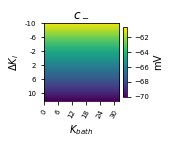

In [71]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$c_-$',fontsize=12)
plt.imshow(mydata_cm,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(201)[::36],np.linspace(-10,10,6).astype(int), rotation=0,fontsize=7)
plt.xticks(np.arange(300)[::56],np.linspace(0,30,6).astype(int), rotation=60,fontsize=7)
plt.xlabel('$K_{bath}$')
plt.ylabel('$\Delta K_{i}$')
plt.tight_layout()
#plt.savefig('Cmin.pdf') 
plt.show()

In [72]:
mydata_cp = genfromtxt(path_abh+'C+_Values.csv', delimiter=',')

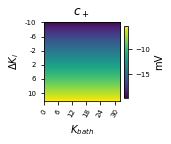

In [73]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.5,2.1))
plt.title('$c_+$',fontsize=12)
plt.imshow(mydata_cp,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.91)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV',fontsize=10)
plt.yticks(np.arange(201)[::36],np.linspace(-10,10,6).astype(int), rotation=0,fontsize=7)
plt.xticks(np.arange(300)[::56],np.linspace(0,30,6).astype(int), rotation=60,fontsize=7)
plt.xlabel('$K_{bath}$')
plt.ylabel('$\Delta K_{i}$')
plt.tight_layout()
plt.savefig('Cplus.pdf') 
plt.show()

In [74]:
mydata_im = genfromtxt(path_abh+'I-_Values.csv', delimiter=',')

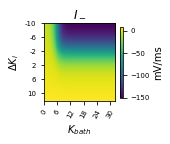

In [75]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$I_-$',fontsize=12)
plt.imshow(mydata_im,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.91)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV/ms',fontsize=10)
plt.yticks(np.arange(201)[::36],np.linspace(-10,10,6).astype(int), rotation=0,fontsize=7)
plt.xticks(np.arange(300)[::56],np.linspace(0,30,6).astype(int), rotation=60,fontsize=7)
plt.xlabel('$K_{bath}$')
plt.ylabel('$\Delta K_{i}$')
plt.tight_layout()
#plt.savefig('Imin.pdf') 
plt.show()

In [76]:
mydata_ip = genfromtxt(path_abh+'I+_Values.csv', delimiter=',')

In [49]:
mydata_ip.shape

(201, 300)

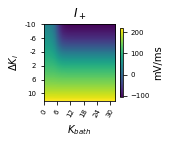

In [77]:
# FID matrix in trial
# Let us plot the matrix of the minima
plt.figure(figsize=(2.4,2.1))
plt.title('$I_+$',fontsize=12)
plt.imshow(mydata_ip,cmap='viridis',interpolation='nearest',aspect='auto');
cbar=plt.colorbar(shrink=0.9)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('mV/ms',fontsize=10)
plt.yticks(np.arange(201)[::36],np.linspace(-10,10,6).astype(int), rotation=0,fontsize=7)
plt.xticks(np.arange(300)[::56],np.linspace(0,30,6).astype(int), rotation=60,fontsize=7)
plt.xlabel('$K_{bath}$')
plt.ylabel('$\Delta K_{i}$')
plt.tight_layout()
#plt.savefig('Iplus.pdf') 
plt.show()